# Smart EV Charging: Optimization, Duality, and Algorithms

---

## Part 1 — Mathematical Formulation

### 1.1 Setting

We manage a parking facility hosting a fleet of $n$ electric vehicles (EVs). Charging takes place over a 24-hour horizon discretized into $T = 48$ time slots of duration $\Delta t = 0.5$ h.

We index vehicles by $i \in \{1,\ldots,n\}$ and time slots by $t \in \{0,\ldots,T-1\}$.

### 1.2 Vehicle model

Each vehicle $i$ is characterized by:

| Symbol | Meaning |
|---|---|
| $a_i \in \{0,\ldots,T-1\}$ | arrival timestep |
| $d_i \in \{a_i+1,\ldots,T\}$ | departure timestep |
| $e_i^{\text{init}}$ | initial state of charge (kWh) |
| $e_i^{\text{req}}$ | required state of charge at departure (kWh) |
| $p_i^{\min}$, $p_i^{\max}$ | minimum and maximum charging power (kW) when charging |

The decision variable for vehicle $i$ is the power profile $p_i = (p_{i,t})_{t=0}^{T-1} \in \mathbb{R}^T$.

#### On/off constraint

At each timestep, the vehicle is either **not charging** ($p_{i,t} = 0$) or **charging** at a power in $[p_i^{\min}, p_i^{\max}]$. Introducing a binary variable $u_{i,t} \in \{0, 1\}$:

$$p_i^{\min}\, u_{i,t} \;\leq\; p_{i,t} \;\leq\; p_i^{\max}\, u_{i,t}, \qquad \forall\, t.$$

#### Availability

The vehicle can only charge while present in the parking:

$$p_{i,t} = 0 \quad \forall\, t \notin [a_i, d_i).$$

#### Energy requirement

The total energy delivered must cover the gap between the initial and required states of charge:

$$\Delta t \sum_{t=a_i}^{d_i - 1} p_{i,t} \;\geq\; e_i^{\text{req}} - e_i^{\text{init}}.$$

#### Feasible set

Gathering all individual constraints, we define:

$$\mathcal{X}_i = \left\{(p_i, u_i) \in \mathbb{R}^T \times \{0,1\}^T \;:\; \text{availability, on/off, and energy constraints for vehicle } i\right\}.$$

### 1.3 Electricity price

A time-varying price signal $c = (c_t)_{t=0}^{T-1} \in \mathbb{R}^T_{\geq 0}$ gives the cost of electricity at each slot (€/kWh). The cost paid for charging vehicle $i$ over the horizon is

$$\Delta t \cdot c^\top p_i.$$

### 1.4 Grid coupling constraint

The total power drawn from the grid cannot exceed a capacity $P^{\max}$ at any timestep:

$$\sum_{i=1}^{n} p_{i,t} \;\leq\; P^{\max}, \qquad \forall\, t \in \{0,\ldots,T-1\}.$$

In vector form, writing $p = (p_1,\ldots,p_n)$:

$$\mathbf{1}^\top_n\, P \;\leq\; P^{\max}\,\mathbf{1}_T,$$

where $P \in \mathbb{R}^{n \times T}$ has rows $p_i^\top$.

### 1.5 Optimization problem

The smart charging problem reads:

$$\boxed{\min_{(p_i, u_i) \in \mathcal{X}_i,\; i=1,\ldots,n} \;\Delta t \sum_{i=1}^{n} c^\top p_i \quad \text{subject to} \quad \sum_{i=1}^{n} p_{i,t} \leq P^{\max},\; \forall\, t.}$$

### 1.6 Problem class

The objective is **linear** in the continuous variables $p_i$. The constraints are linear in $(p_i, u_i)$. The binary variables $u_{i,t} \in \{0,1\}$ make this a **Mixed-Integer Linear Program (MILP)**.

Modern solvers (HiGHS, Gurobi, CPLEX, …) can handle MILPs via branch-and-bound. However, as we will see, the problem becomes intractable for large $n$ when solved "frontally".

---

## Part 2 — Numerical Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

from data_loader import generate_fleet, generate_prices, generate_problem
import cvxpy as cp

%pip install cvxopt

MILP_SOLVER = cp.GLPK_MI if cp.GLPK_MI in cp.installed_solvers() else cp.HIGHS
print(MILP_SOLVER)

Note: you may need to restart the kernel to use updated packages.
GLPK_MI


### 2.1 Generate a problem instance

We fix $T = 48$ timesteps (30-min resolution over 24 hours) and start with a small fleet $n = 10$.

In [2]:
T = 48          # 24 h at 30-min resolution (starts at 12:00)
n = 10

prob = generate_problem(n=n, T=T, seed=42)

print(f"Number of vehicles : {prob['n']}")
print(f"Number of timesteps: {prob['T']}")
print(f"Horizon            : {int(prob['start_time']):02d}:00 → {int(prob['start_time'])+24:02d}:00")
print(f"Grid capacity P_max: {prob['P_max']:.1f} kW")
print(f"p_min / p_max      : {prob['p_min'][0]:.1f} / {prob['p_max'][0]:.1f} kW  (shared by all vehicles)")
print(f"Battery capacity   : {prob['capacity']:.0f} kWh  (shared by all vehicles)")
print(f"\nSample vehicle 0:")
print(f"  Arrival / departure: t={prob['arrival'][0]} / t={prob['departure'][0]}")
print(f"  SoC init / required: {prob['soc_init'][0]:.1f} / {prob['soc_req'][0]:.1f} kWh")

def time_axis(prob):
    """Return (t_hours, tick_positions, tick_labels) for plots."""
    T, dt, t0 = prob['T'], prob['dt'], prob['start_time']
    t_hours = t0 + np.arange(T) * dt
    tick_pos = np.arange(t0, t0 + 24 + 1, 3)          # every 3 h
    tick_labels = [f"{int(h) % 24:02d}:00" for h in tick_pos]
    return t_hours, tick_pos, tick_labels

Number of vehicles : 10
Number of timesteps: 48
Horizon            : 12:00 → 36:00
Grid capacity P_max: 250.0 kW
p_min / p_max      : 30.0 / 100.0 kW  (shared by all vehicles)
Battery capacity   : 300 kWh  (shared by all vehicles)

Sample vehicle 0:
  Arrival / departure: t=10 / t=36
  SoC init / required: 63.4 / 266.9 kWh


### 2.2 Visualize the price signal

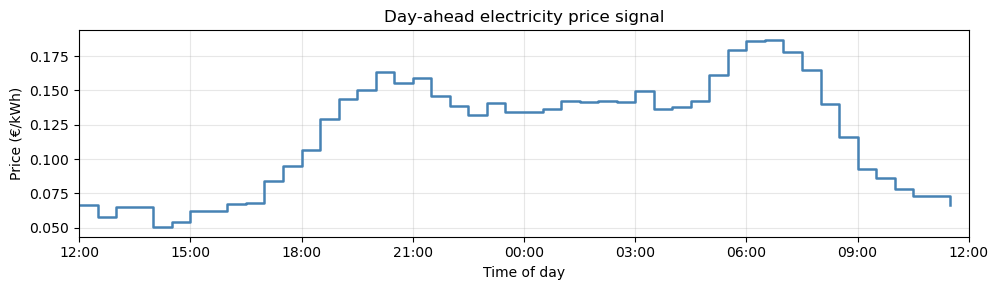

In [3]:
prices = prob['prices']
t_hours, tick_pos, tick_labels = time_axis(prob)

fig, ax = plt.subplots(figsize=(10, 3))
ax.step(t_hours, prices, where='post', color='steelblue', linewidth=1.8)
ax.set_xlabel('Time of day')
ax.set_ylabel('Price (€/kWh)')
ax.set_title('Day-ahead electricity price signal')
ax.set_xlim(t_hours[0], t_hours[-1] + prob['dt'])
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Visualize vehicle availability

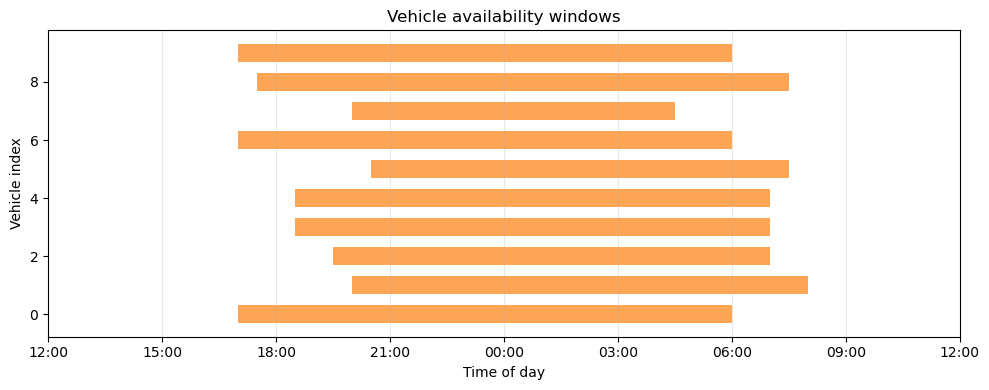

In [4]:
t_hours, tick_pos, tick_labels = time_axis(prob)
dt = prob['dt']

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(min(n, 15)):
    a, d = prob['arrival'][i], prob['departure'][i]
    left  = prob['start_time'] + a * dt
    width = (d - a) * dt
    ax.barh(i, width, left=left, height=0.6, color='tab:orange', alpha=0.7)
ax.set_xlabel('Time of day')
ax.set_ylabel('Vehicle index')
ax.set_title('Vehicle availability windows')
ax.set_xlim(t_hours[0], t_hours[-1] + dt)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 3 — Frontal MILP Solve with CVXPY

### 3.1 Warm-up: a tiny MILP with CVXPY

Before tackling the full problem, let's get familiar with CVXPY's MILP interface.

**Example** — integer knapsack:

$$\max_{x \in \{0,1\}^4} \; v^\top x \quad \text{s.t.} \quad w^\top x \leq W$$

with $v = [10, 6, 4, 5]$, $w = [5, 4, 3, 2]$, $W = 8$.

Reference: [CVXPY documentation](https://www.cvxpy.org/)

In [5]:

v = np.array([10, 6, 4, 5], dtype=float)
w = np.array([5,  4, 3, 2], dtype=float)
W = 8.0

x = cp.Variable(4, boolean=True)

constraints_knapsack = [w @ x <= W]
objective_knapsack = cp.Maximize(v @ x)

prob_knapsack = cp.Problem(objective_knapsack, constraints_knapsack)
prob_knapsack.solve(solver=cp.HIGHS)

print(f"Status : {prob_knapsack.status}")
print(f"Optimal value : {prob_knapsack.value:.1f}")
print(f"Optimal x     : {x.value.astype(int)}")

Status : optimal
Optimal value : 15.0
Optimal x     : [1 0 0 1]


### 3.2 MILP formulation of the EV charging problem

Recall our problem:

$$\min_{p_i,\, u_i} \;\Delta t \sum_{i} c^\top p_i$$

subject to, for each vehicle $i$ and each timestep $t$:

- $p_{i,t} = 0$ if $t \notin [a_i, d_i)$  
- $p_i^{\min} u_{i,t} \leq p_{i,t} \leq p_i^{\max} u_{i,t}$  
- $\Delta t \sum_t p_{i,t} \geq e_i^{\text{req}} - e_i^{\text{init}}$  
- $u_{i,t} \in \{0, 1\}$

and the coupling constraint:

- $\sum_i p_{i,t} \leq P^{\max}$ for all $t$.

> **Your turn!** Implement the function below.

In [6]:
def compute_primal_cost(P, prob_data):
    """Compute total cost of charging profile P given price signal."""
    cost = 0
    prices = prob_data['prices']
    dt = prob_data['dt']
    for i in range(prob_data['n']):
        cost += np.sum(P[i, :] @ prices) * dt
    return cost

def compute_coupling_infeasibility(P, prob_data, ord=2):
    """Compute coupling infeasibility of charging profile P."""
    return np.linalg.norm(np.maximum(0, P.sum(axis=0) - prob_data['P_max']), ord=ord)

In [7]:
def build_and_solve_milp(prob_data, verbose=False):
    """
    Build and solve the EV smart charging MILP using CVXPY + HiGHS.

    Args:
        prob_data : dict returned by generate_problem()
        verbose   : whether to print solver output

    Returns:
        status    : solver status string
        obj_val   : optimal objective value (€), or None if infeasible
        P_opt     : optimal power matrix of shape (n, T), or None
        solve_time: wall-clock solve time in seconds
    """
    n       = prob_data['n']
    T       = prob_data['T']
    dt      = prob_data['dt']
    arr     = prob_data['arrival']
    dep     = prob_data['departure']
    soc0    = prob_data['soc_init']
    socreq  = prob_data['soc_req']
    pmin    = prob_data['p_min']
    pmax    = prob_data['p_max']
    prices  = prob_data['prices']
    P_max   = prob_data['P_max']

    # --- Decision variables ---
    P = cp.Variable((n, T), nonneg=True)         # power profiles
    U = cp.Variable((n, T), boolean=True)         # on/off indicators

    constraints = []


    # --- Fill in the following code ----
    for i in range(n):
        a_i, d_i = arr[i], dep[i]

        # Availability: no charging outside parking window
        if a_i > 0:
            constraints += [P[i, :a_i] == 0, U[i, :a_i] == 0]
        if d_i < T:
            constraints += [P[i, d_i:] == 0, U[i, d_i:] == 0]

        # On/off: p_min * u <= p <= p_max * u
        constraints += [
            P[i, :] >= pmin[i] * U[i, :],
            P[i, :] <= pmax[i] * U[i, :],
        ]

        # Energy requirement
        constraints += [
            dt * cp.sum(P[i, a_i:d_i]) >= socreq[i] - soc0[i]
        ]

    # Coupling: grid capacity at each timestep
    constraints += [cp.sum(P, axis=0) <= P_max]

    # Objective: minimize total electricity cost
    objective = cp.Minimize(dt * cp.sum(prices @ P.T))


    # --- End of the code to fill in ---
    problem = cp.Problem(objective, constraints)

    t0 = time.time()
    problem.solve(solver=cp.HIGHS, verbose=verbose)
    solve_time = time.time() - t0

    if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
        return problem.status, problem.value, P.value, solve_time
    else:
        return problem.status, None, None, solve_time

### 3.3 Solve for a small instance and inspect the solution

In [8]:
n_small = 10
prob_small = generate_problem(n=n_small, T=T, seed=42)

status, obj, P_opt, t_solve = build_and_solve_milp(prob_small, verbose=False)

print(f"Status     : {status}")
print(f"Solve time : {t_solve:.2f} s")
print(f"Total cost : {obj:.2f} €")

Status     : optimal
Solve time : 0.42 s
Total cost : 216.68 €


In [9]:
compute_primal_cost(P_opt, prob_small), compute_coupling_infeasibility(P_opt, prob_small)

(np.float64(216.67535084698304), np.float64(0.0))

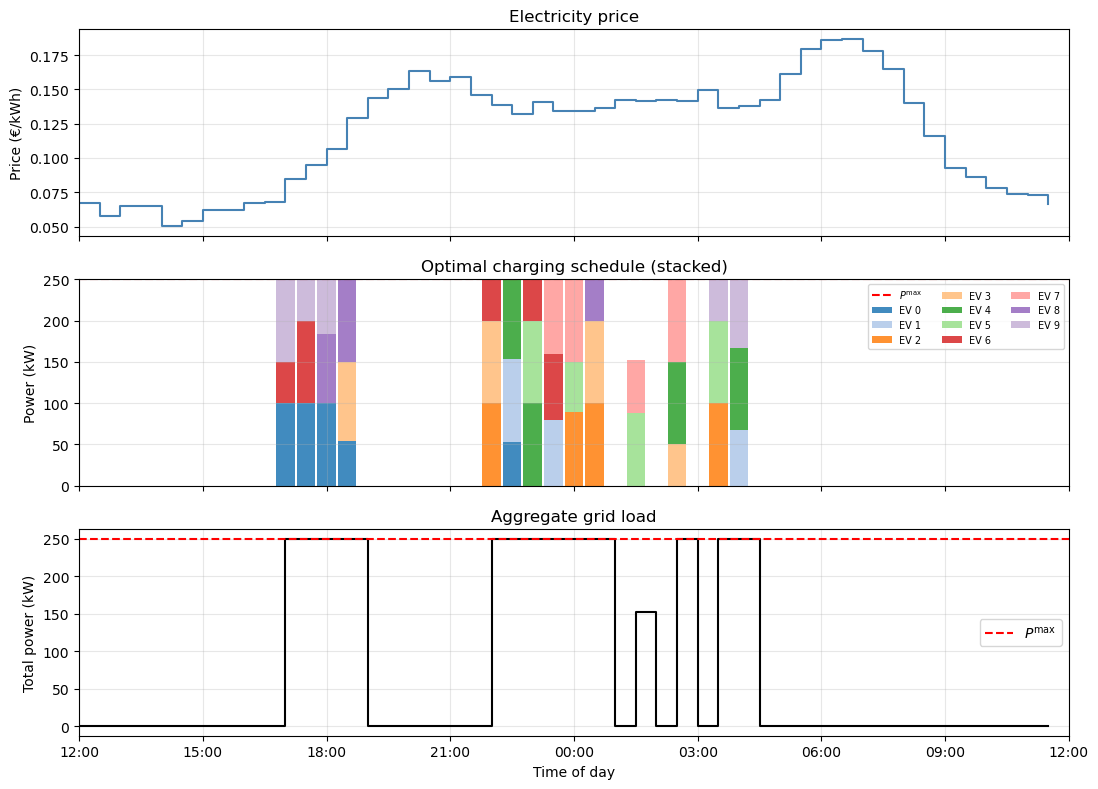

In [10]:
t_hours, tick_pos, tick_labels = time_axis(prob_small)
dt = prob_small['dt']

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

# Price
axes[0].step(t_hours, prob_small['prices'], where='post', color='steelblue')
axes[0].set_ylabel('Price (€/kWh)')
axes[0].set_title('Electricity price')
axes[0].grid(alpha=0.3)

# Per-vehicle power profiles (stacked)
bottom = np.zeros(T)
cmap = plt.get_cmap('tab20')
for i in range(n_small):
    axes[1].bar(t_hours, P_opt[i], bottom=bottom, width=dt * 0.9,
                color=cmap(i), label=f'EV {i}', alpha=0.85)
    bottom += P_opt[i]
axes[1].axhline(prob_small['P_max'], color='red', linestyle='--', label='$P^{\\max}$')
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Optimal charging schedule (stacked)')
axes[1].legend(loc='upper right', fontsize=7, ncol=3)
axes[1].grid(alpha=0.3)

# Total grid load
axes[2].step(t_hours, P_opt.sum(axis=0), where='post', color='black')
axes[2].axhline(prob_small['P_max'], color='red', linestyle='--', label='$P^{\\max}$')
axes[2].set_ylabel('Total power (kW)')
axes[2].set_xlabel('Time of day')
axes[2].set_title('Aggregate grid load')
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[2].set_xlim(t_hours[0], t_hours[-1] + dt)
axes[2].set_xticks(tick_pos)
axes[2].set_xticklabels(tick_labels)

plt.tight_layout()
plt.show()

### 3.4 Scalability experiment

Let's run the MILP solver for increasing values of $n$ and record the solve time.

> **Question**: at what fleet size does the solver become impractical (say, >60 s)?

In [11]:
fleet_sizes = [5, 10, 20, 50, 100]
results = []

for n_test in fleet_sizes:
    prob_test = generate_problem(n=n_test, T=T, seed=42)
    status, obj, _, t_solve = build_and_solve_milp(prob_test)
    results.append({'n': n_test, 'status': status, 'obj': obj, 'time': t_solve})
    print(f"n={n_test:4d} | status={status:<15s} | obj={obj if obj else float('nan'):8.2f} € | time={t_solve:.2f} s")

n=   5 | status=optimal         | obj=  112.69 € | time=0.07 s
n=  10 | status=optimal         | obj=  216.68 € | time=0.42 s


/opt/anaconda3/envs/summer_school_tp/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


n=  20 | status=optimal         | obj=  447.26 € | time=0.25 s
n=  50 | status=optimal         | obj= 1156.29 € | time=0.81 s
n= 100 | status=optimal         | obj= 2229.84 € | time=1.72 s


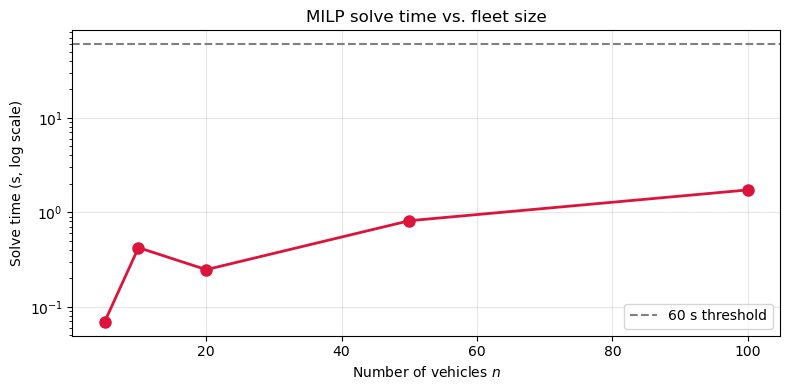

In [12]:
n_vals   = [r['n'] for r in results if r['obj'] is not None]
t_vals   = [r['time'] for r in results if r['obj'] is not None]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(n_vals, t_vals, 'o-', color='crimson', linewidth=2, markersize=8)
ax.axhline(60, color='gray', linestyle='--', label='60 s threshold')
ax.set_xlabel('Number of vehicles $n$')
ax.set_ylabel('Solve time (s, log scale)')
ax.set_title('MILP solve time vs. fleet size')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Takeaway**: branch-and-bound solves this MILP efficiently for small fleets ($n \lesssim 1000$), but solve times increase fast. For $n \sim 1500$ the problem becomes intractable in real-time operation.

This motivates the next parts of the tutorial: **relaxations**, **duality**, and **decomposition algorithms** that can scale to large fleets.

---

## Part 4 — Lagrangian Relaxation and Duality

### 4.1 Motivation

The MILP scales poorly because the coupling constraint $\sum_i p_{i,t} \leq P^{\max}$ ties all vehicles together, forcing branch-and-bound to explore joint assignments. The key observation is: **if we remove this constraint, the problem decouples into $n$ independent single-vehicle MILPs**, each solvable in milliseconds.

Lagrangian relaxation does exactly this.

### 4.2 Lagrangian relaxation

Recall

$$\min_{(p_i, u_i) \in \mathcal{X}_i} \Delta t \sum_{i=1}^n c^\top p_i  \quad \text{ such that } \quad \sum_{i=1}^n p_i \leq P^{\max}$$

Introduce a dual variable $\lambda = (\lambda_t)_{t=0}^{T-1} \in \mathbb{R}^T_{\geq 0}$, one per timestep, penalizing violations of the coupling constraint. The **Lagrangian** is:

$$L(p, u, \lambda) \;=\; \Delta t \sum_{i=1}^{n} c^\top p_i \;+\; \lambda^\top \!\left(\sum_{i=1}^{n} p_i - P^{\max} \right).$$

Regrouping by vehicle:

$$L(p, u, \lambda) \;=\; -P^{\max} \mathbf{1}^\top \lambda \;+\; \sum_{i=1}^{n} (\Delta t\,c + \lambda)^\top p_i.$$


### 4.3 Dual function and decomposition

Minimizing the Lagrangian over all feasible $(p_i, u_i) \in \mathcal{X}_i$ gives the **dual function**:

$$g(\lambda) \;=\; \min_{\substack{(p_i, u_i) \in \mathcal{X}_i \\ i=1,\ldots,n}} L(p, u, \lambda) \;=\; -P^{\max} \mathbf{1}^\top \lambda \;+\; \sum_{i=1}^{n} \underbrace{\min_{(p_i, u_i) \in \mathcal{X}_i} (\Delta t \, c + \lambda)^\top p_i}_{=:\; g_i(\lambda)}.$$

### 4.4 Dual problem

By weak duality, $g(\lambda) \leq$ (primal optimum) for all $\lambda \geq 0$. The **Lagrangian dual** finds the tightest lower bound:

$$\boxed{d^* = \max_{\lambda \geq 0}\; g(\lambda).}$$

Since $g$ is a pointwise infimum of affine functions of $\lambda$, it is **concave**.

**For the remainder of this tutorial, we will focus on solving the dual problem, using common algorithms that were studied in this morning's lecture. Time permitting, we will see how to relate solutions of the dual to the primal problem at the very end of the tutorial**

### 4.5 Subgradient of $g$

Although $g$ is concave, it is generally non-smooth. Let $p_i^*(\lambda)$ denote any minimizer of $g_i(\lambda)$, i.e.

$$ p_i^*(\lambda) \in \argmin_{(p_i, u_i) \in \mathcal{X}_i} \left\{ (\Delta t\, c + \lambda)^\top p_i \right\}. \tag{1} $$

The **subgradient** of $g$ at $\lambda$ is:

$$\partial g(\lambda) \;=\; \sum_{i=1}^{n} p_{i}^*(\lambda) - P^{\max}$$

**Interpretation**: it measures by how much the decoupled solutions collectively violate the coupling constraint. When $\nabla g(\lambda)_t > 0$, the grid limit is exceeded at time $t$ — the dual price $\lambda_t$ should increase to discourage charging.

### 4.6 Subgradient method

The subgradient method performs gradient **ascent** on $g$, projecting onto $\lambda \geq 0$:

$$\lambda^{(k+1)} \;=\; \max\!\left(0,\; \lambda^{(k)} + \alpha_k\, g_{\lambda_k} \right) $$

where $g_{\lambda_k} \in \partial g\!\left(\lambda^{(k)}\right)$, the $\max$ is componentwise and $\alpha_k > 0$ is a step size. 


### 4.7 Convergence rate

A standard choice is the **diminishing step** $\alpha_k = \alpha_0 / \sqrt{k}$. After $k$ iterations of the subgradient method, one can show that the averaged iterate $\bar{\lambda}_k$ satisfies (recall this morning's lecture)

$$ d^* - d(\bar{\lambda}_k) \leq O\left( \frac{||\lambda_0 - \lambda^*||^2}{\alpha_0 \sqrt{k}} + \frac{\alpha_0 G^2 }{\sqrt{k}}\right). \tag{2} $$

The ideal choice is then $\alpha_0 \approx \frac{||\lambda_0 - \lambda^*||}{G}$. 

We unfortunately do not know $||\lambda_0 - \lambda^*||$ nor $G$.

In practice a grid search is often necessary to set $\alpha_0$.

### 4.8 Summary

To compute the subgradient of the dual function $d$, we need to solve $n$ independent single-vehicle MILPs in parallel, then sum their outputs — linear in $n$, independent of the coupling structure.

---

## Part 5 — Implementing the Subgradient Method

### 5.1 Single-vehicle MILP (inner problem)

The building block is solving, for a given $\lambda \in \mathbb{R}^T$:

$$g_i(\lambda) = \min_{(p_i, u_i) \in \mathcal{X}_i}\; (\Delta t \, c + \lambda)^\top p_i.$$

This is similar to the single-vehicle feasibility problem from Part 3.

> **Your turn!** Implement `solve_vehicle_milp` below. You can cvxpy just like we did earlier

In [13]:
def solve_vehicle_milp(i, lam, prob_data, solver=cp.HIGHS):
    """
    Solve the inner MILP for vehicle i given dual variable lambda.

    min_{(p_i, u_i) in X_i}  dt * c^T p_i + lambda^T p_i
    
    Args:
        i         : vehicle index
        lam       : dual variable, array of shape (T,)
        prob_data : dict from generate_problem()

    Returns:
        p_opt : optimal power profile for vehicle i, array of shape (T,)
        g_i   : optimal value dt * c^T p_opt + lam^T p_opt
    """
    T      = prob_data['T']
    dt     = prob_data['dt']
    a_i    = prob_data['arrival'][i]
    d_i    = prob_data['departure'][i]
    soc0   = prob_data['soc_init'][i]
    socreq = prob_data['soc_req'][i]
    pmin   = prob_data['p_min'][i]
    pmax   = prob_data['p_max'][i]

    p = cp.Variable(T, nonneg=True)
    u = cp.Variable(T, boolean=True)

    constraints = []

    # --- Fill in the following code ---

    # Availability
    if a_i > 0:
        constraints += [p[:a_i] == 0, u[:a_i] == 0]
    if d_i < T:
        constraints += [p[d_i:] == 0, u[d_i:] == 0]

    # On/off
    constraints += [p >= pmin * u, p <= pmax * u]

    # Energy requirement
    constraints += [dt * cp.sum(p[a_i:d_i]) >= socreq - soc0]

    # Lagrangian cost: dt * c^T p  +  lambda^T p  (penalty NOT scaled by dt)
    objective = cp.Minimize(dt * (prob_data['prices'] @ p) + lam @ p)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=solver)

    ### --- End of code to fill in ---

    p_opt = p.value if prob.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE] else np.zeros(T)
    return p_opt, prob.value

### 5.2 Dual function and subgradient

Given $\lambda$, compute $g(\lambda)$ and $\nabla g(\lambda)$ by solving all $n$ vehicle subproblems and aggregating.

> **Your turn!** Implement the function computing the gradient and subgradient below

In [14]:
def dual_and_subgradient(lam, prob_data, solver=cp.HIGHS):
    """
    Evaluate the dual function g(lambda) and its subgradient.

    g(lambda) = -P_max * sum(lambda) + sum_i g_i(lambda)

    subgradient_t = sum_i p_{i,t}^*(lambda) - P_max

    Returns:
        g_val : float, value of the dual function
        grad  : array (T,), subgradient of g at lambda
        P_dec : array (n, T), decoupled power profiles
    """
    n     = prob_data['n']
    T     = prob_data['T']
    P_max = prob_data['P_max']

    # --- Fill in the following code ---
    P_dec  = np.zeros((n, T))
    g_val  = -P_max * lam.sum()

    for i in range(n):
        p_opt, g_i = solve_vehicle_milp(i, lam, prob_data, solver=solver)
        P_dec[i]   = p_opt
        g_val     += g_i

    grad = P_dec.sum(axis=0) - P_max
    return g_val, grad, P_dec

### 5.3 Subgradient method

> **Your turn!** Implement the subgradient algorithm below.

In [15]:
def subgradient_method(prob_data, n_iter, alpha0, verbose_every=10, milp_solver=cp.HIGHS):
    """
    Maximize g(lambda) via the subgradient method.
    """

    # --- Fill in the following code ---
    T   = prob_data['T']
    n = prob_data['n']
    lam = np.zeros(T)           # start from lambda = 0
    lam_avg = lam.copy()       # for averaging
    Xk = np.zeros((n, T))       # to store decoupled solutions

    start_time = time.time()

    history = {}
    history['nb_calls_single_vehicle_milp'] = []
    history['dual_values'] = []
    history['iteration'] = []
    history['time'] = []
    history['primal_cost'] = []
    history['coupling_infeas'] = []

    nb_calls_single_vehicle_milp = 0

    for k in range(n_iter):
        alpha_k = alpha0 / np.sqrt(k + 1)

        _, grad, P_dec = dual_and_subgradient(lam, prob_data, solver=milp_solver)
        nb_calls_single_vehicle_milp += n

        # Gradient ascent step + projection onto lambda >= 0
        lam = np.maximum(0.0, lam + alpha_k * grad)
        lam_avg = ((k+1) * lam_avg + lam) / (k + 2)  # running average

        #update primal solution
        Xk = (k * Xk  + P_dec) / (k + 1)

        #optimization accounting
        if k % verbose_every == 0:
            g_val_avg, _, _ = dual_and_subgradient(lam_avg, prob_data, solver=milp_solver)

            history['iteration'].append(k)
            history['time'].append(time.time() - start_time)
            history['nb_calls_single_vehicle_milp'].append(nb_calls_single_vehicle_milp)

            history['dual_values'].append(g_val_avg)
            history['primal_cost'].append(compute_primal_cost(Xk, prob_data))
            history['coupling_infeas'].append(compute_coupling_infeasibility(Xk, prob_data))

            print(f"  iter {k:4d} | g(λ_avg) = {g_val_avg:10.2f} ")

    return history, time.time() - start_time, Xk

### 5.4 Run and compare

Run the subgradient method on a small instance (say `n=10`) and perform a grid search to find a good value of $\alpha_0$.

a) What happens when the value of $\alpha_0$ is too small ? when it is too large ?

b) compare the dual value obtained to the primal optimum found by the MILP solver.

c) Let $d^*$ be the best dual value you have found accross all runs. Plot the value $d^* - d(\lambda_k)$ as a function of the number of iterations $k$.

d) Put the above plot in log-log scale. For comparison, add the curves $\frac{1}{\sqrt{k}}$, $\frac{1}{k}$ and $\frac{1}{k^2}$. Relate this to the rate in equation (2) above.

In [ ]:
prob_dual = generate_problem(n=10, T=T, seed=42)

n_iter = 400
verbose_every = 50
alpha_0_list = [ 1e-6, 1e-5, 1e-4, 1e-3]
histories_subgradient = {}

for alpha0 in alpha_0_list:
    print(f"Running subgradient method with alpha0={alpha0}...")
    history, _, _ = subgradient_method(prob_dual, n_iter=n_iter, alpha0=alpha0, verbose_every=verbose_every, milp_solver=MILP_SOLVER)
    histories_subgradient[alpha0] = history

#get best dual value among all runs
best_dual_value = max(max(history['dual_values']) for history in histories_subgradient.values())
print(f"\nBest dual value across all runs: {best_dual_value:.2f}")

# Compare to primal optimum (already computed above)
_, obj_milp, _, _ = build_and_solve_milp(prob_dual, verbose=False)
print(f"\nPrimal optimum (MILP)  : {obj_milp:.2f} €")
print(f"Best dual bound        : {best_dual_value:.2f} €")
print(f"Duality gap            : {obj_milp - best_dual_value:.2f} €")

Running subgradient method with alpha0=1e-06...
  iter    0 | g(λ_avg) =     206.32 
  iter   50 | g(λ_avg) =     208.26 
  iter  100 | g(λ_avg) =     208.73 
  iter  150 | g(λ_avg) =     209.01 
  iter  200 | g(λ_avg) =     209.23 
  iter  250 | g(λ_avg) =     209.41 
  iter  300 | g(λ_avg) =     209.56 
  iter  350 | g(λ_avg) =     209.71 
Running subgradient method with alpha0=1e-05...
  iter    0 | g(λ_avg) =     207.58 
  iter   50 | g(λ_avg) =     212.75 
  iter  100 | g(λ_avg) =     214.05 
  iter  150 | g(λ_avg) =     214.58 
  iter  200 | g(λ_avg) =     214.88 
  iter  250 | g(λ_avg) =     215.08 
  iter  300 | g(λ_avg) =     215.23 
  iter  350 | g(λ_avg) =     215.34 
Running subgradient method with alpha0=0.0001...
  iter    0 | g(λ_avg) =     199.15 
  iter   50 | g(λ_avg) =     207.17 
  iter  100 | g(λ_avg) =     209.98 
  iter  150 | g(λ_avg) =     211.31 
  iter  200 | g(λ_avg) =     212.12 
  iter  250 | g(λ_avg) =     212.67 
  iter  300 | g(λ_avg) =     213.06 
  it

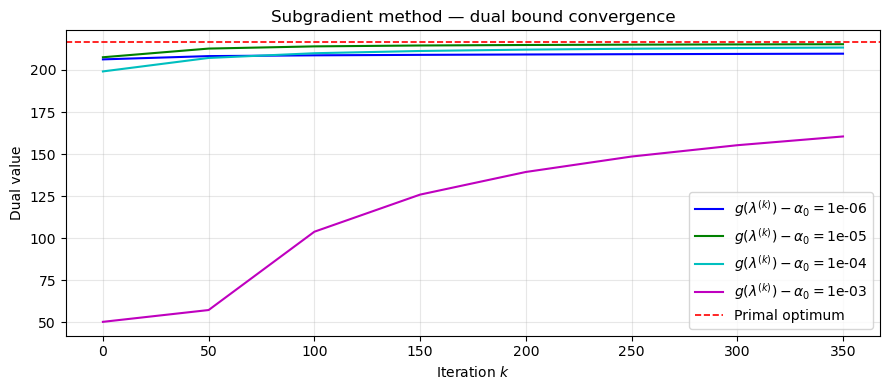

In [22]:
colors = ['b', 'g', 'c', 'm', 'y', 'k', 'w']

linear_inverse_curve = [10/(k+1) for k in histories_subgradient[alpha_0_list[0]]['iteration']]
sqrt_inverse_curve = [10/np.sqrt(k+1) for k in histories_subgradient[alpha_0_list[0]]['iteration']]


fig, ax = plt.subplots(1, 1, figsize=(9, 4))

color_number = 0
# Dual bound convergence
for alpha0, history in histories_subgradient.items():
    ax.plot(history['iteration'], history['dual_values'], color=colors[color_number], linewidth=1.5, label='$g(\\lambda^{(k)}) - \\alpha_0 = $' + f'{alpha0:.0e}')
    color_number = (color_number + 1) % len(colors)
ax.axhline(obj_milp, color='red', linestyle='--', linewidth=1.2, label='Primal optimum')
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('Dual value')
ax.set_title('Subgradient method — dual bound convergence')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Scalability of the subgradient method

Unlike the monolithic MILP, each iteration of the subgradient method requires only $n$ **independent** small MILPs. Run it on a large fleet and compare the per-iteration time to the frontal solve.

In [22]:
n_large = 100
prob_large = generate_problem(n=n_large, T=T, seed=42)


history, run_time, _ = subgradient_method(prob_large, n_iter=50, alpha0=1e-5, verbose_every=10)
print(f"\nn={n_large}: subgradient (50 iters) took {run_time:.1f} s  →  {run_time/50:.2f} s/iter")

  iter    1 | g(λ_avg) =    2048.85 
  iter   11 | g(λ_avg) =    2038.59 
  iter   21 | g(λ_avg) =    2094.62 
  iter   31 | g(λ_avg) =    2121.48 
  iter   41 | g(λ_avg) =    2138.86 

n=100: subgradient (50 iters) took 33.5 s  →  0.67 s/iter


**Takeaway**: the subgradient method trades the global MILP for many small per-vehicle MILPs. Each iteration scales linearly in $n$ and the vehicle subproblems are trivially parallelizable. However without access to parallel computers the running time is still quite high.

---

## Part 6 — Stochastic Subgradient Ascent

### 6.1 Bottleneck of the deterministic algorithm

Each iteration of the subgradient method requires solving **all $n$ vehicle MILPs** to evaluate $\partial g(\lambda)$. For large $n$ this is the dominant cost — even though each single-vehicle MILP is tiny, doing $n$ of them sequentially makes one iteration expensive, as we observed in Section 5.5.

### 6.2 Finite-sum structure

Look again at the dual function:

$$g(\lambda) = -P^{\max} \mathbf{1}^\top \lambda + \sum_{i=1}^{n} g_i(\lambda).$$

Distributing the constant term evenly, we can write $g$ as a **finite sum** of $n$ terms:

$$g(\lambda) = \sum_{i=1}^{n} h_i(\lambda), \qquad h_i(\lambda) \;=\; g_i(\lambda) - \frac{P^{\max}}{n}\,\mathbf{1}^\top \lambda.$$

A subgradient of $h_i$ at $\lambda$ is:

$$ p_{i}^*(\lambda) - \frac{P^{\max}}{n}, \qquad t = 0,\ldots,T-1.$$

### 6.3 Stochastic subgradient

At each iteration $k$, instead of summing over all $n$ vehicles, **sample one vehicle uniformly** $i_k \sim \text{Uniform}\{1,\ldots,n\}$ and use the scaled estimate:

$$\hat{s}^{(k)}_t \;=\; n\, p_{i_k}^*(\lambda^{(k)}) - P^{\max}.$$

This is an **unbiased** estimator of the true subgradient:

$$\mathbb{E}_{i_k}\!\left[\hat{s}^{(k)}\right] \;=\;   \frac{1}{n}\sum_{i=1}^n \left( n p_{i_k}^*(\lambda^{(k)}) - P^{\max}\right) \;=\; \partial g(\lambda^{(k)}).$$

### 6.4 Stochastic subgradient ascent

The update rule is identical in form to the deterministic case:

$$\lambda^{(k+1)} = \max\!\left(0,\; \lambda^{(k)} + \alpha_k\,\hat{s}^{(k)}\right),$$

but each iteration now costs exactly **one single-vehicle MILP call** instead of $n$.

### 6.5 Convergence rates

After $k$ iterations, the same rate that applied for the deterministic algorithm holds for the stochastic algorithm (in expectation)

$$ \mathbb{E} \left[ d^* - d(\bar{\lambda}_k) \right] \leq O\left( \frac{||\lambda_0 - \lambda^*||^2}{\alpha_0 \sqrt{T}} + \frac{\alpha_0 G^2 }{\sqrt{T}}\right) $$

---

## Part 7 — Implementing and Comparing the Stochastic Algorithm

### 7.1 Stochastic subgradient method

> **Your turn!** Implement `stochastic_subgradient_method` below

In [ ]:
def stochastic_subgradient_method(prob_data, n_iter, alpha0, verbose_every=100, rng_seed=0, milp_solver=cp.HIGHS):
    """
    Maximize g(lambda) via the stochastic subgradient method.
    """
    # --- Fill in the following code

    T     = prob_data['T']
    n     = prob_data['n']
    P_max = prob_data['P_max']
    rng   = np.random.default_rng(rng_seed)

    lam     = np.zeros(T)
    lam_avg = np.zeros(T)

    #intialize Xk to store primal iterates (useful only at the end of the tutorial)
    Xk = np.zeros((n, T))
    index_counters = np.ones(n)
    for i in range(n):
        p_opt, _ = solve_vehicle_milp(i, lam, prob_data)
        Xk[i, :] = p_opt

    #Optimization accounting
    start = time.time()
    history = {
        'nb_calls_single_vehicle_milp': [],
        'iteration': [],
        'time': [],
        'dual_values': [],
        'primal_cost': [],
        'coupling_infeas': []
    }
    nb_calls = 0

    for k in range(n_iter):
        alpha_k = alpha0 / np.sqrt(k + 1)

        # Sample one vehicle and compute stochastic subgradient
        i_k = rng.integers(0, n)
        p_opt, _ = solve_vehicle_milp(i_k, lam, prob_data, solver=milp_solver)
        nb_calls += 1

        s_hat = n * p_opt - P_max          # unbiased estimate of grad g

        #dual gradient ascent step
        lam     = np.maximum(0.0, lam + alpha_k * s_hat)
        lam_avg = ((k + 1) * lam_avg + lam) / (k + 2)

        #update primal
        Xk[i_k, :] = (index_counters[i_k] * Xk[i_k, :] + p_opt) / (index_counters[i_k] + 1)
        index_counters[i_k] += 1

        if (k) % verbose_every == 0:
            g_val_avg, _, _ = dual_and_subgradient(lam_avg, prob_data, solver=milp_solver)
            nb_calls += n                  # evaluation cost

            history['iteration'].append(k)
            history['nb_calls_single_vehicle_milp'].append(nb_calls)
            history['time'].append(time.time() - start)

            history['dual_values'].append(g_val_avg)
            history['primal_cost'].append(compute_primal_cost(Xk, prob_data))
            history['coupling_infeas'].append(compute_coupling_infeasibility(Xk, prob_data))
            
            print(f"  iter {k:5d} | g(λ_avg) = {g_val_avg:10.2f}")

    return history, time.time() - start, Xk

### 7.2 Run both algorithms and collect histories

We use $n=30$ vehicles so the deterministic/stochastic gap is clearly visible. 

> **Your turn!** Compare the deterministic and stochastic algorithms:

a) When both have the same number of iterations

b) With the same number of calls to the single vehicle MILP solver

We give the stochastic algorithm $n$ times more iterations so both use the same total number of single-vehicle MILP calls.

In [ ]:
n = 100
prob = generate_problem(n=n, T=T, seed=42)
alpha0_cmp = 1e-5

n_iter = 1000

verbose_every = 10

alpha_0_list = [ 1e-6, 1e-5]
histories_subgradient = {}

for alpha0 in alpha_0_list:
    print(f"Running subgradient method with alpha0={alpha0}...")
    history, _, _ = stochastic_subgradient_method(prob, 
                                       n_iter=n_iter, 
                                       alpha0=alpha0, 
                                       verbose_every=verbose_every, 
                                       milp_solver=MILP_SOLVER)
    histories_subgradient[alpha0] = history

#get best dual value among all runs
best_dual_value = max(max(history['dual_values']) for history in histories_subgradient.values())
print(f"\nBest dual value across all runs: {best_dual_value:.2f}")

#get best dual value among all runs
best_dual_value = max(max(history['dual_values']) for history in histories_subgradient.values())
print(f"\nBest dual value across all runs: {best_dual_value:.2f}")

# Compare to primal optimum (already computed above)
_, obj_milp, _, _ = build_and_solve_milp(prob, verbose=False)
print(f"\nPrimal optimum (MILP)  : {obj_milp:.2f} €")
print(f"Best dual bound        : {best_dual_value:.2f} €")
print(f"Duality gap            : {obj_milp - best_dual_value:.2f} €")

Running subgradient method with alpha0=1e-06...
  iter     1 | g(λ_avg) =    2194.30
  iter    11 | g(λ_avg) =    2215.35
  iter    21 | g(λ_avg) =    2217.62
  iter    31 | g(λ_avg) =    2219.79
  iter    41 | g(λ_avg) =    2220.47
  iter    51 | g(λ_avg) =    2220.92
  iter    61 | g(λ_avg) =    2221.71
  iter    71 | g(λ_avg) =    2222.15
  iter    81 | g(λ_avg) =    2222.76
  iter    91 | g(λ_avg) =    2223.06
  iter   101 | g(λ_avg) =    2223.48
  iter   111 | g(λ_avg) =    2223.75
  iter   121 | g(λ_avg) =    2223.91
  iter   131 | g(λ_avg) =    2224.16
  iter   141 | g(λ_avg) =    2224.37
  iter   151 | g(λ_avg) =    2224.49
  iter   161 | g(λ_avg) =    2224.62
  iter   171 | g(λ_avg) =    2224.67
  iter   181 | g(λ_avg) =    2224.74
  iter   191 | g(λ_avg) =    2224.82
  iter   201 | g(λ_avg) =    2225.00
  iter   211 | g(λ_avg) =    2225.12
  iter   221 | g(λ_avg) =    2225.27
  iter   231 | g(λ_avg) =    2225.44
  iter   241 | g(λ_avg) =    2225.56
  iter   251 | g(λ_avg) =  

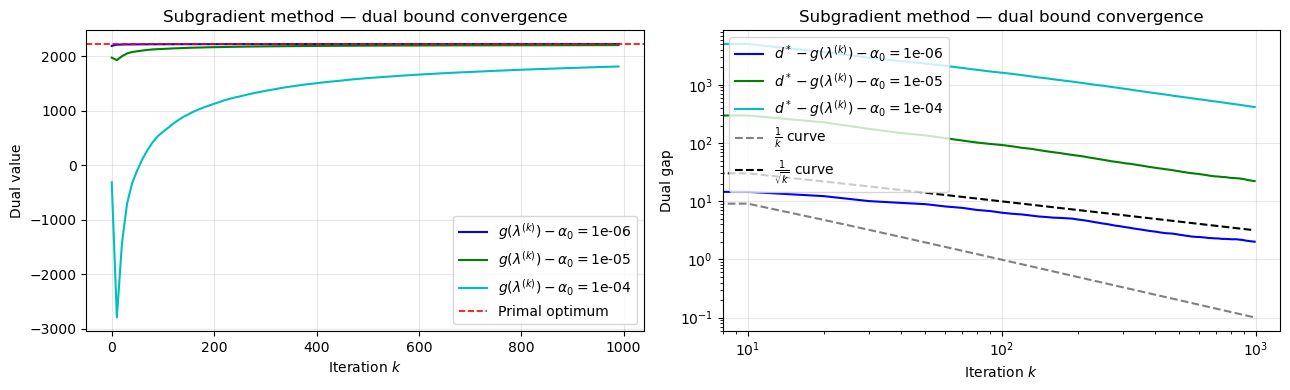

In [52]:
colors = ['b', 'g', 'c', 'm', 'y', 'k', 'w']

linear_inverse_curve = [100/(k+1) for k in histories_subgradient[alpha_0_list[0]]['iteration']]
sqrt_inverse_curve = [100/np.sqrt(k+1) for k in histories_subgradient[alpha_0_list[0]]['iteration']]


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

color_number = 0
# Dual bound convergence
for alpha0, history in histories_subgradient.items():
    axes[0].plot(history['iteration'], history['dual_values'], color=colors[color_number], linewidth=1.5, label='$g(\\lambda^{(k)}) - \\alpha_0 = $' + f'{alpha0:.0e}')
    color_number = (color_number + 1) % len(colors)
axes[0].axhline(obj_milp, color='red', linestyle='--', linewidth=1.2, label='Primal optimum')
axes[0].set_xlabel('Iteration $k$')
axes[0].set_ylabel('Dual value')
axes[0].set_title('Subgradient method — dual bound convergence')
axes[0].legend()
axes[0].grid(alpha=0.3)

color_number = 0
for alpha0, history in histories_subgradient.items():
    axes[1].plot(history['iteration'], obj_milp - np.array(history['dual_values']), color=colors[color_number], linewidth=1.5, label='$d^* - g(\\lambda^{(k)}) - \\alpha_0 = $' + f'{alpha0:.0e}')
    color_number = (color_number + 1) % len(colors)

axes[1].plot(history['iteration'], linear_inverse_curve, color="gray", linestyle="--", label=r"$\frac{1}{k}$ curve")
axes[1].plot(history['iteration'], sqrt_inverse_curve, color="black", linestyle="--", label=r"$\frac{1}{\sqrt{k}}$ curve")
axes[1].set_xlabel('Iteration $k$')
axes[1].set_ylabel('Dual gap')
axes[1].set_title('Subgradient method — dual bound convergence')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

### 7.4 Scalability of the stochastic subgradient method

In [ ]:
n_large = 2000
prob_large = generate_problem(n=n_large, T=T, seed=42)
n_iter = 10000


history, run_time, _ = stochastic_subgradient_method(prob_large, 
                                                     n_iter=n_iter, 
                                                     alpha0=1e-5, 
                                                     verbose_every=1000, 
                                                     milp_solver=MILP_SOLVER)
print(f"\nn={n_large}: subgradient took {run_time:.1f} s for {n_iter} iterations")

  iter     1 | g(λ_avg) =  -69336.20
  iter  1001 | g(λ_avg) =   24194.09
  iter  2001 | g(λ_avg) =   31494.93
  iter  3001 | g(λ_avg) =   34560.87
  iter  4001 | g(λ_avg) =   36305.43
  iter  5001 | g(λ_avg) =   37472.76
  iter  6001 | g(λ_avg) =   38312.89
  iter  7001 | g(λ_avg) =   38963.46
  iter  8001 | g(λ_avg) =   39477.04
  iter  9001 | g(λ_avg) =   39904.57

n=2000: subgradient took 148.3 s  →  2.97 s/iter


### 7.5 To go further on the (stochastic) subgradient methods (time permitting)

When calling the single MILP solver with cvxpy, most of the actual run time is not spent actually solving the problem, but rather factorizing it in the desired mathematical form to feed it to the HiGHs solver. 

Since we call each single MILP solver numerous times throughout the course of (stochastic) subgradient algorithm, we can compute this factorization once and for all and save it in memory. This is often called a **cache** of the problem, and leads to considerable speedups for iterative algorithms.

You can find a reference on how to cache problems here: https://www.cvxpy.org/tutorial/solvers/index.html

> **Your turn:** Implement the cached version of the stochastic subgradient algorithm and observe the speedups it gives compared to the uncached version

In [54]:
def dual_and_subgradient_cached(lam, prob_data, cache, milp_solver=cp.HIGHS):
    """
    Evaluate the dual function g(lambda) and its subgradient.

    g(lambda) = -P_max * sum(lambda) + sum_i g_i(lambda)

    subgradient_t = sum_i p_{i,t}^*(lambda) - P_max

    Returns:
        g_val : float, value of the dual function
        grad  : array (T,), subgradient of g at lambda
        P_dec : array (n, T), decoupled power profiles
    """
    n     = prob_data['n']
    T     = prob_data['T']
    P_max = prob_data['P_max']

    # --- Fill in the following code ---
    P_dec  = np.zeros((n, T))
    g_val  = -P_max * lam.sum()

    for i in range(n):
        p_opt, g_i = solve_vehicle_milp_cache(i, lam, cache, solver=milp_solver)
        P_dec[i]   = p_opt
        g_val     += g_i

    grad = P_dec.sum(axis=0) - P_max
    return g_val, grad, P_dec



def build_vehicle_milp_cache(i, prob_data):
    """
    Solve the inner MILP for vehicle i given dual variable lambda.

    min_{(p_i, u_i) in X_i}  dt * c^T p_i + lambda^T p_i
    
    Args:
        i         : vehicle index
        lam       : dual variable, array of shape (T,)
        prob_data : dict from generate_problem()

    Returns:
        p_opt : optimal power profile for vehicle i, array of shape (T,)
        g_i   : optimal value dt * c^T p_opt + lam^T p_opt
    """
    T      = prob_data['T']
    dt     = prob_data['dt']
    a_i    = prob_data['arrival'][i]
    d_i    = prob_data['departure'][i]
    soc0   = prob_data['soc_init'][i]
    socreq = prob_data['soc_req'][i]
    pmin   = prob_data['p_min'][i]
    pmax   = prob_data['p_max'][i]

    p = cp.Variable(T, nonneg=True)
    u = cp.Variable(T, boolean=True)

    constraints = []

    # --- Fill in the following code ---

    # Availability
    if a_i > 0:
        constraints += [p[:a_i] == 0, u[:a_i] == 0]
    if d_i < T:
        constraints += [p[d_i:] == 0, u[d_i:] == 0]

    # On/off
    constraints += [p >= pmin * u, p <= pmax * u]

    # Energy requirement
    constraints += [dt * cp.sum(p[a_i:d_i]) >= socreq - soc0]

    # Lagrangian cost: dt * c^T p  +  lambda^T p  (penalty NOT scaled by dt)
    lam = cp.Parameter(T)
    objective = cp.Minimize(dt * (prob_data['prices'] @ p) + lam @ p)
    prob = cp.Problem(objective, constraints)
    
    cache = {"prob": prob, "p": p, "lam":lam}
    return cache

def solve_vehicle_milp_cache(i, lam, cache, solver=cp.HIGHS):
    cache_i = cache[i]
    cache_i["lam"].value = lam
    cache_i["prob"].solve(solver=solver)
    return cache_i["p"].value, cache_i["prob"].value



def stochastic_subgradient_method_cached(prob_data, n_iter, alpha0, verbose_every=100, rng_seed=0, milp_solver=cp.HIGHS):
    """
    Maximize g(lambda) via the stochastic subgradient method.
    """
    # --- Fill in the following code

    T     = prob_data['T']
    n     = prob_data['n']
    P_max = prob_data['P_max']
    rng   = np.random.default_rng(rng_seed)

    lam     = np.zeros(T)
    lam_avg = np.zeros(T)

    cache = {}
    for i in range(n):
        cache[i] = build_vehicle_milp_cache(i, prob_data=prob_data)

    #intialize Xk to store primal iterates
    Xk = np.zeros((n, T))
    index_counters = np.ones(n)
    for i in range(n):
        p_opt, _ = solve_vehicle_milp_cache(i, lam, cache=cache, solver=milp_solver)
        Xk[i, :] = p_opt

    start = time.time()
    history = {
        'nb_calls_single_vehicle_milp': [],
        'iteration': [],
        'time': [],
        'dual_values': [],
        'primal_cost': [],
        'coupling_infeas': []
    }
    nb_calls = 0

    for k in range(n_iter):
        alpha_k = alpha0 / np.sqrt(k + 1)

        # Sample one vehicle and compute stochastic subgradient
        i_k = rng.integers(0, n)
        p_opt, _ = solve_vehicle_milp_cache(i_k, lam, cache, solver=milp_solver)
        nb_calls += 1

        s_hat = n * p_opt - P_max          # unbiased estimate of grad g

        #dual gradient ascent step
        lam     = np.maximum(0.0, lam + alpha_k * s_hat)
        lam_avg = ((k + 1) * lam_avg + lam) / (k + 2)

        #update primal
        Xk[i_k, :] = (index_counters[i_k] * Xk[i_k, :] + p_opt) / (index_counters[i_k] + 1)
        index_counters[i_k] += 1

        if (k + 1) % verbose_every == 0:
            g_val_avg, _, _ = dual_and_subgradient_cached(lam_avg, prob_data, cache, milp_solver=milp_solver)
            nb_calls += n                  # evaluation cost

            history['iteration'].append(k)
            history['nb_calls_single_vehicle_milp'].append(nb_calls)
            history['time'].append(time.time() - start)

            history['dual_values'].append(g_val_avg)
            history['primal_cost'].append(compute_primal_cost(Xk, prob_data))
            history['coupling_infeas'].append(compute_coupling_infeasibility(Xk, prob_data))
            
            print(f"  iter {k+1:5d} | g(λ_avg) = {g_val_avg:10.2f}")

    return history, time.time() - start, lam_avg, Xk

In [ ]:
n_large = 2000
prob_large = generate_problem(n=n_large, T=T, seed=42)
n_iter = 10000


history, run_time, lam_avg, Xk = stochastic_subgradient_method_cached(prob_large, 
                                                                      n_iter=n_iter, 
                                                                      alpha0=1e-5, 
                                                                      verbose_every=1000,
                                                                      milp_solver=MILP_SOLVER)
print(f"\nn={n_large}: subgradient took {run_time:.1f} s  →  {run_time/n_iter:.2f} s/iter")

  iter  1000 | g(λ_avg) =   24181.68
  iter  2000 | g(λ_avg) =   31490.53
  iter  3000 | g(λ_avg) =   34559.40
  iter  4000 | g(λ_avg) =   36303.71
  iter  5000 | g(λ_avg) =   37472.25
  iter  6000 | g(λ_avg) =   38311.88
  iter  7000 | g(λ_avg) =   38963.08
  iter  8000 | g(λ_avg) =   39476.71
  iter  9000 | g(λ_avg) =   39904.31
  iter 10000 | g(λ_avg) =   40260.66

n=2000: subgradient took 29.9 s  →  0.00 s/iter


---

## Part 8 — Going back to the primal (time permitting)

### 8.1 Primal solution from the solution of the dual

After solving the dual problem through the (stochastic) subgradient algorithm on the dual, we obtain a candidate dual optimal value $\bar{\lambda}_k$. One might then think that a good primal solution is the primal value minimizing the Lagrangian evaluated at this dual value, i.e.

$$ (p^*, u^*) \in \argmin_{(p_i, u_i) \in \mathcal{X}_i} \, L(p, u, \bar{\lambda}_k) $$

> **Your turn!** For a small toy problem, implement this scheme and look at
1) the primal problem at $(p^*, u^*)$ compared to the optimal primal value obtained by the frontal MILP solver
2) the infeasibility of the resulting problem, namely $|| \left[\sum_{i} p^*_i - P^{\max}\right]_+ ||$


In [ ]:
n = 500
prob = generate_problem(n=n, T=T, seed=42)

#solve the MILP first
_, obj_milp, _, _ = build_and_solve_milp(prob, verbose=False)

n_iter = 50000

history, run_time, lam_avg, Xk = stochastic_subgradient_method_cached(prob, 
                                                                      n_iter=n_iter, 
                                                                      alpha0=1e-5, 
                                                                      verbose_every=1000,
                                                                      milp_solver=MILP_SOLVER)

  iter  1000 | g(λ_avg) =   10450.19
  iter  2000 | g(λ_avg) =   10757.68
  iter  3000 | g(λ_avg) =   10878.06
  iter  4000 | g(λ_avg) =   10941.71
  iter  5000 | g(λ_avg) =   10983.77
  iter  6000 | g(λ_avg) =   11015.00
  iter  7000 | g(λ_avg) =   11038.51
  iter  8000 | g(λ_avg) =   11054.98
  iter  9000 | g(λ_avg) =   11067.61
  iter 10000 | g(λ_avg) =   11079.06
  iter 11000 | g(λ_avg) =   11088.99
  iter 12000 | g(λ_avg) =   11097.08
  iter 13000 | g(λ_avg) =   11104.47
  iter 14000 | g(λ_avg) =   11110.92
  iter 15000 | g(λ_avg) =   11116.94
  iter 16000 | g(λ_avg) =   11122.57
  iter 17000 | g(λ_avg) =   11127.73
  iter 18000 | g(λ_avg) =   11132.43
  iter 19000 | g(λ_avg) =   11136.62
  iter 20000 | g(λ_avg) =   11140.80
  iter 21000 | g(λ_avg) =   11144.55
  iter 22000 | g(λ_avg) =   11147.79
  iter 23000 | g(λ_avg) =   11151.20
  iter 24000 | g(λ_avg) =   11154.45
  iter 25000 | g(λ_avg) =   11157.46
  iter 26000 | g(λ_avg) =   11160.01
  iter 27000 | g(λ_avg) =   11162.48
 

In [72]:
# First get the primal variable minimizing the Lagrangian at the output of the subradient algorithm: lam_avg
P = np.zeros((n, T))
for i in range(n):
    P[i, :] = solve_vehicle_milp(i, lam_avg, prob_data=prob)[0]

In [73]:
print(obj_milp, compute_primal_cost(P, prob_data=prob), compute_coupling_infeasibility(P, prob_data=prob))

11282.255390184386 11299.539422620392 34711.17138178784


### 8.2 Averaging the primal points encountered throughout the dual algorithms

At each iteration of the stochastic algorithm, when solving the single vehicle milp program, we obtain a feasible charging scenario $p_{i_k}^*(\lambda_k)$.

It turns out that taking the average of those scenarios produces a solution which converges and whose infeasibility goes to 0.

> **Your turn** Change your stochastic subgradient code to incorporate those changes:
1) For each vehicle $i$, your code should keep track of a primal solution $p_i^k$ which is the average of result of the single vehicle milp solved at iterations $t$ for which $i_t = i$.
2) compare the resulting charging scenario $\{p_i^k\}_{i=1}^n$ to the optimal primal value obtained by the fronal MILP solver and the infeasibility $|| \left[\sum_{i} p^k_i - P^{\max}\right]_+ ||$ as a function of the number of iterations $k$.


This technique is known to provide primal solutions at rate $O(\sqrt{\frac{N}{T}})$, see for example:

[1] Nedic, A., Ozdaglar, A.: *Approximate primal solutions and rate analysis for dual subgradient methods*. SIAM Journal on Optimization

[2] Dubois-Taine, Pfeiffer, Oudjane, Seguret, Bach. : *Two-stage stochastic algorithm for solving large-scale (non)-convex separable optimization problems under affine constraints*.

In [74]:
print(compute_primal_cost(Xk, prob_data=prob), compute_coupling_infeasibility(Xk, prob_data=prob, ord=np.inf))

11293.17358676704 277.08838817261676


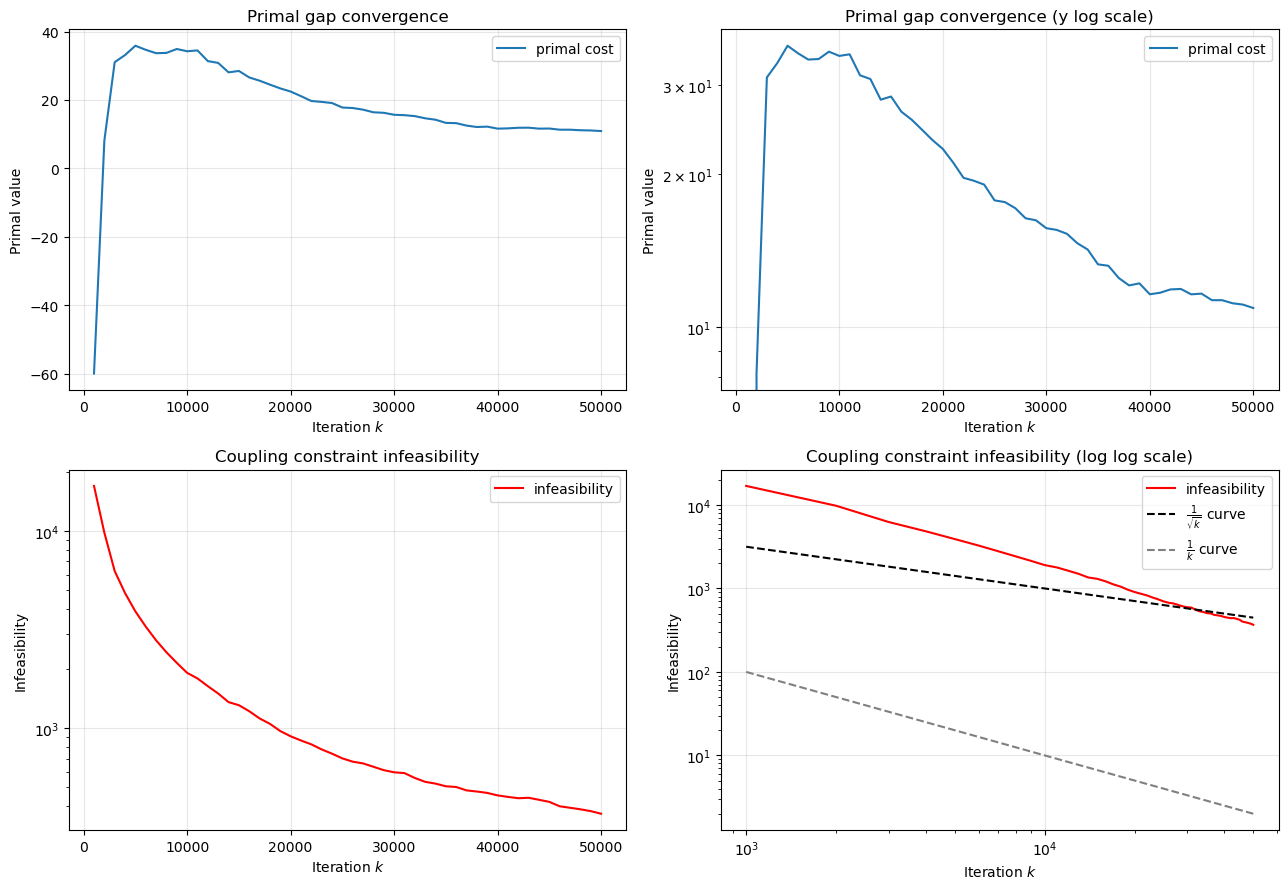

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

color_number = 0

sqrt_inverse_curve = [100000/np.sqrt(k+1) for k in history['iteration']]
linear_inverse_curve = [100000/(k+1) for k in history['iteration']]

axes[0, 0].plot(history['iteration'], np.array(history['primal_cost']) - obj_milp, label="primal cost")
axes[0, 0].set_xlabel('Iteration $k$')
axes[0, 0].set_ylabel('Primal value')
axes[0, 0].set_title('Primal gap convergence')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['iteration'], np.array(history['primal_cost']) - obj_milp, label="primal cost")
axes[0, 1].set_xlabel('Iteration $k$')
axes[0, 1].set_ylabel('Primal value')
axes[0, 1].set_title('Primal gap convergence (y log scale)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
#axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")


axes[1, 0].plot(history['iteration'], np.array(history['coupling_infeas']), label="infeasibility", color='red')
axes[1, 0].set_xlabel('Iteration $k$')
axes[1, 0].set_ylabel('Infeasibility')
axes[1, 0].set_title('Coupling constraint infeasibility')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_yscale("log")

axes[1, 1].plot(history['iteration'], np.array(history['coupling_infeas']), label="infeasibility", color='red')
axes[1, 1].plot(history['iteration'], sqrt_inverse_curve, color="black", linestyle="--", label=r"$\frac{1}{\sqrt{k}}$ curve")
axes[1, 1].plot(history['iteration'], linear_inverse_curve, color="gray", linestyle="--", label=r"$\frac{1}{k}$ curve")
axes[1, 1].set_xlabel('Iteration $k$')
axes[1, 1].set_ylabel('Infeasibility')
axes[1, 1].set_title('Coupling constraint infeasibility (log log scale)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

---

## Part 9: Summary and going further

> **What is the main problem with going the technique described in 8.2 ?**

The power profiles $p_i$ generated this way are averages of outputs of the single vehicle MILP. In particular, they might not be feasible themselves...


Reference for final convexification effect via Shapley-Folkman/Caratheodory:

[3] Aubin, J.P., Ekeland, I., *Estimates of the duality gap in nonconvex optimization*. Mathematics of Operations Research 

[4] Dubois-Taine, d'Aspremont: *Frank-Wolfe meets Shapley-Folkman: a systematic approach for solving nonconvex separable problems with linear constraints*. Mathematical Programming.